In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

In [2]:
folder_single_run = '../outputs/2026-06-21/22-29-33/'

In [3]:
df = pd.read_csv(os.path.join(folder_single_run, 'training_loss.csv'))

<Axes: xlabel='step', ylabel='total_loss'>

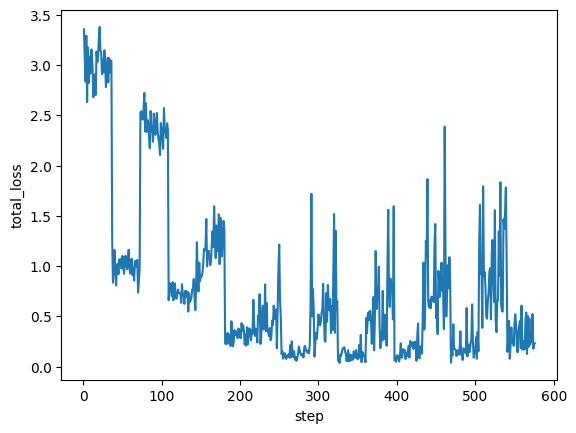

In [4]:
sns.lineplot(x='step', y='total_loss', data=df)

In [5]:
steps = np.load(os.path.join(folder_single_run, 'loss_autoencoding_steps.npy'))
loss_autoencoding = np.load(os.path.join(folder_single_run, 'loss_autoencoding_net0.npy'))

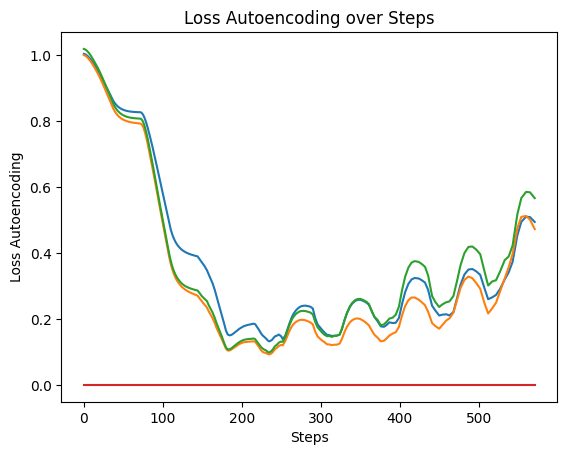

In [6]:
plt.plot(steps, loss_autoencoding)
plt.xlabel('Steps')
plt.ylabel('Loss Autoencoding')
plt.title('Loss Autoencoding over Steps')
plt.show()

In [7]:
prediction = np.load(os.path.join(folder_single_run, 'prediction_combined_color.npy'))

In [8]:
import json
with open(folder_single_run + 'prediction_rows.json', 'r') as f:
    row_info = json.load(f)

In [9]:
row_info

[{'subgroup': 'high_sim', 'group_id': 1, 'item_id': 1},
 {'subgroup': 'high_sim', 'group_id': 1, 'item_id': 2},
 {'subgroup': 'high_sim', 'group_id': 2, 'item_id': 1},
 {'subgroup': 'high_sim', 'group_id': 2, 'item_id': 2},
 {'subgroup': 'high_sim', 'group_id': 3, 'item_id': 1},
 {'subgroup': 'high_sim', 'group_id': 3, 'item_id': 2},
 {'subgroup': 'high_sim', 'group_id': 4, 'item_id': 1},
 {'subgroup': 'high_sim', 'group_id': 4, 'item_id': 2},
 {'subgroup': 'high_sim', 'group_id': 5, 'item_id': 1},
 {'subgroup': 'high_sim', 'group_id': 5, 'item_id': 2},
 {'subgroup': 'high_sim', 'group_id': 6, 'item_id': 1},
 {'subgroup': 'high_sim', 'group_id': 6, 'item_id': 2},
 {'subgroup': 'med_sim', 'group_id': 1, 'item_id': 1},
 {'subgroup': 'med_sim', 'group_id': 1, 'item_id': 2},
 {'subgroup': 'med_sim', 'group_id': 2, 'item_id': 1},
 {'subgroup': 'med_sim', 'group_id': 2, 'item_id': 2},
 {'subgroup': 'med_sim', 'group_id': 3, 'item_id': 1},
 {'subgroup': 'med_sim', 'group_id': 3, 'item_id': 2}

In [10]:
ground_truth = np.load(os.path.join(folder_single_run, 'prediction_target_color.npy'))

In [11]:
pred = prediction[-1, 0, :64]
other = prediction[-1, 1, :64]
gt_pred = ground_truth[0,:64]
gt_other = ground_truth[1,:64]

In [12]:
def signed_circular_mean_angle(rho):
    n = len(rho)
    theta = 2 * np.pi * np.arange(n) / n

    Z = rho.sum()
    if np.isclose(Z, 0):
        raise ValueError("sum(rho) is zero")

    z = np.sum(rho * np.exp(1j * theta)) / Z
    return np.rad2deg(np.angle(z))

In [13]:
i = 0
t = 200

In [14]:
import numpy as np

def signed_angle(origin, target, x):
    """
    Signed angle of x relative to origin.
    Positive means toward target.
    Negative means away from target.

    Returns angle in degrees in (-180, 180].
    """
    # Build orthonormal basis of the plane
    e1 = origin / np.linalg.norm(origin)

    v = target - np.dot(target, e1) * e1
    e2 = v / np.linalg.norm(v)

    def angle(y):
        return np.arctan2(np.dot(y, e2), np.dot(y, e1))

    a0 = angle(origin)
    a1 = angle(target)
    ax = angle(x)

    wrap = lambda a: (a + np.pi) % (2 * np.pi) - np.pi

    return -np.degrees(
        np.sign(wrap(a1 - a0)) * wrap(ax - a0)
    )

In [15]:
repulsion_metric = []
for t in range(prediction.shape[0]):
    _repulsion_metric = []
    for i in range(ground_truth.shape[1] // 64):
        gt1 = (ground_truth[2*i,(64*i):(64*(i+1))])
        gt2 = (ground_truth[2*i+1,(64*i):(64*(i+1))])
        pred1 = (prediction[t,2*i,(64*i):(64*(i+1))])
        pred2 = (prediction[t,2*i+1,(64*i):(64*(i+1))])
        _repulsion_metric.extend([signed_angle(gt1, gt2, pred1), signed_angle(gt2, gt1, pred2)])
    _repulsion_metric = np.array(_repulsion_metric)
    repulsion_metric.append(_repulsion_metric)
repulsion_metric = np.stack(repulsion_metric)

In [16]:
row_info[0]

{'subgroup': 'high_sim', 'group_id': 1, 'item_id': 1}

In [17]:
high_sim = repulsion_metric[:,[r['subgroup']=='high_sim' for r in row_info]]
med_sim = repulsion_metric[:,[r['subgroup']=='med_sim' for r in row_info]]
low_sim = repulsion_metric[:,[r['subgroup']=='low_sim' for r in row_info]]

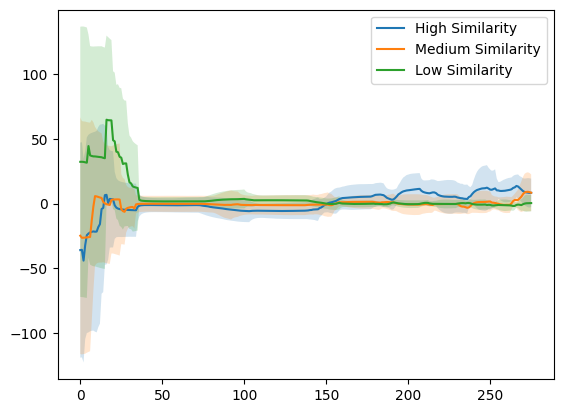

In [18]:
# Plot mean and std similarity across different similarity conditions
plt.plot(high_sim.mean(axis=1), label='High Similarity')
plt.fill_between(np.arange(high_sim.shape[0]), high_sim.mean(axis=1) - high_sim.std(axis=1), high_sim.mean(axis=1) + high_sim.std(axis=1), alpha=0.2)
plt.plot(med_sim.mean(axis=1), label='Medium Similarity')
plt.fill_between(np.arange(med_sim.shape[0]), med_sim.mean(axis=1) - med_sim.std(axis=1), med_sim.mean(axis=1) + med_sim.std(axis=1), alpha=0.2)
plt.plot(low_sim.mean(axis=1), label='Low Similarity')
plt.fill_between(np.arange(low_sim.shape[0]), low_sim.mean(axis=1) - low_sim.std(axis=1), low_sim.mean(axis=1) + low_sim.std(axis=1), alpha=0.2)
plt.legend()
plt.show()

In [19]:
high_sim

array([[-140.90144985,  124.9804577 , -118.33316162, ...,  -70.37835278,
          53.57016402,  -67.61038141],
       [-140.90115878,  125.00003662, -118.7176796 , ...,  -68.35901301,
          54.14897045,  -68.3018635 ],
       [-141.37379619,  124.46919372, -119.91782905, ...,  -66.39296005,
          55.11781314,  -68.12679043],
       ...,
       [   2.71314024,    8.18384058,   10.4072016 , ...,   -2.39382944,
          28.69076718,   -4.17905383],
       [   2.71431774,    8.26729297,   10.22782059, ...,   -2.32360206,
          28.61735505,   -5.18299905],
       [   2.85423169,    8.33040816,   10.2220462 , ...,   -2.24054164,
          27.66982172,   -3.34945443]], shape=(276, 12))

In [20]:

def oriented_angle(theta0, theta1, theta):
    """
    Signed angular displacement from theta0.

    Positive means moving from theta0 toward theta1.
    Negative means moving away from theta1.

    All angles are in radians.
    Returns value in (-pi, pi].
    """
    def wrap(a):
        return (a + np.pi) % (2 * np.pi) - np.pi

    direction = np.sign(wrap(theta1 - theta0))
    if direction == 0:
        raise ValueError("theta0 and theta1 coincide")

    return direction * wrap(theta - theta0)

In [21]:
import numpy as np

def directed_arc_coordinate(theta0, theta1, theta):
    """
    Signed coordinate on the circle.

    Positive values lie in the direction from theta0 toward theta1.
    Negative values lie in the opposite direction.
    """

    def ccw(a, b):
        return (b - a) % 360

    # Decide which way is "positive"
    d01 = ccw(theta0, theta1)

    if d01 == 0:
        raise ValueError("theta0 and theta1 coincide")

    if d01 <= 180:
        # positive = counterclockwise
        pos = ccw(theta0, theta)
        neg = ccw(theta, theta0)
    else:
        # positive = clockwise
        pos = ccw(theta, theta0)
        neg = ccw(theta0, theta)

    return -pos if pos <= neg else neg

In [24]:
gt1

array([8.22728351e-02, 1.80839136e-01, 3.19082022e-01, 4.51945662e-01,
       5.13859093e-01, 4.69003290e-01, 3.43622565e-01, 2.02097714e-01,
       9.54146683e-02, 3.61611992e-02, 1.10013112e-02, 2.68670567e-03,
       5.26707678e-04, 8.28882985e-05, 1.04710616e-05, 1.06184757e-06,
       8.64385825e-08, 5.64842084e-09, 2.96292352e-10, 1.24763568e-11,
       4.21724748e-13, 1.14431178e-14, 2.49249106e-16, 4.35809660e-18,
       6.11693730e-20, 6.89199828e-22, 6.23347553e-24, 4.52573723e-26,
       2.63768167e-28, 1.23404046e-30, 4.63458007e-33, 1.39722169e-35,
       3.38138196e-38, 6.56900694e-41, 1.02294788e-43, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 3.36311631e-44, 2.24333871e-41,
       1.19834967e-38, 5.13859384e-36, 1.76880125e-33, 4.88751085e-31,
       1.08410260e-28, 1.93030966e-26, 2.75903747e-24, 3.16564454e-22,
       2.91568532e-20, 2.15572408e-18, 1.27943903e-16, 6.09565016e-15,
       2.33127997e-13, 7.15719367e-12, 1.76386405e-10, 3.48948537e-09,
      

In [25]:
gt2

array([1.28578687e-14, 4.70606789e-13, 1.38267887e-11, 3.26105726e-10,
       6.17404128e-09, 9.38327744e-08, 1.14475768e-06, 1.12110574e-05,
       8.81360320e-05, 5.56204410e-04, 2.81766453e-03, 1.14582460e-02,
       3.74042504e-02, 9.80161726e-02, 2.06180930e-01, 3.48155439e-01,
       4.71923798e-01, 5.13504803e-01, 4.48529601e-01, 3.14493507e-01,
       1.77013442e-01, 7.99787790e-02, 2.90079620e-02, 8.44566151e-03,
       1.97389512e-03, 3.70329624e-04, 5.57733583e-05, 6.74278181e-06,
       6.54373025e-07, 5.09783327e-08, 3.18801097e-09, 1.60039801e-10,
       6.44926387e-12, 2.08624947e-13, 5.41746730e-15, 1.12927663e-16,
       1.88963683e-18, 2.53822617e-20, 2.73688311e-22, 2.36895147e-24,
       1.64600080e-26, 9.18074374e-29, 4.11054764e-31, 1.47739096e-33,
       4.26250760e-36, 9.87208462e-39, 1.83542073e-41, 2.80259693e-44,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.26116862e-43,
       8.01808968e-41, 4.09892328e-38, 1.68207488e-35, 5.54108531e-33,
      

In [26]:
pred2

array([ 9.38877929e-03,  2.28732787e-02,  3.59558687e-02,  4.95842770e-02,
        5.77710234e-02,  5.61139472e-02,  3.88361812e-02,  2.59928554e-02,
        1.08153056e-02,  3.67408874e-03,  1.36276148e-03,  6.32544141e-03,
        1.81370787e-02,  4.54950221e-02,  9.72779468e-02,  1.66261762e-01,
        2.21995920e-01,  2.39182562e-01,  2.09494635e-01,  1.49039090e-01,
        8.34577829e-02,  3.79537866e-02,  1.48873953e-02,  3.81722953e-03,
       -5.27106225e-04, -2.11317372e-03, -2.76435982e-03,  1.36602065e-03,
        2.65974412e-03, -8.59960681e-04, -1.14655192e-03,  1.38630066e-03,
        7.42554199e-04,  8.92681535e-04, -1.94321387e-04,  2.39334768e-03,
       -1.45961589e-03,  1.40285282e-03, -1.06578053e-04, -7.73895532e-04,
       -2.68265000e-03, -2.99723120e-04, -2.32569454e-03, -1.72899058e-03,
        2.87556462e-03,  9.71585512e-04, -7.82720745e-04,  1.82153913e-03,
        1.71575975e-03,  8.64370028e-04,  3.14351171e-04, -1.87552010e-04,
        1.04476907e-03, -

In [27]:
print(gt1, gt2, pred2)

[8.22728351e-02 1.80839136e-01 3.19082022e-01 4.51945662e-01
 5.13859093e-01 4.69003290e-01 3.43622565e-01 2.02097714e-01
 9.54146683e-02 3.61611992e-02 1.10013112e-02 2.68670567e-03
 5.26707678e-04 8.28882985e-05 1.04710616e-05 1.06184757e-06
 8.64385825e-08 5.64842084e-09 2.96292352e-10 1.24763568e-11
 4.21724748e-13 1.14431178e-14 2.49249106e-16 4.35809660e-18
 6.11693730e-20 6.89199828e-22 6.23347553e-24 4.52573723e-26
 2.63768167e-28 1.23404046e-30 4.63458007e-33 1.39722169e-35
 3.38138196e-38 6.56900694e-41 1.02294788e-43 0.00000000e+00
 0.00000000e+00 0.00000000e+00 3.36311631e-44 2.24333871e-41
 1.19834967e-38 5.13859384e-36 1.76880125e-33 4.88751085e-31
 1.08410260e-28 1.93030966e-26 2.75903747e-24 3.16564454e-22
 2.91568532e-20 2.15572408e-18 1.27943903e-16 6.09565016e-15
 2.33127997e-13 7.15719367e-12 1.76386405e-10 3.48948537e-09
 5.54155477e-08 7.06440915e-07 7.22926325e-06 5.93862896e-05
 3.91608686e-04 2.07296712e-03 8.80859140e-03 3.00465412e-02] [1.28578687e-14 4.70606

In [28]:
np.rad2deg(signed_circular_mean_angle(ground_truth[1,:64]))

np.float64(-3287.39247064914)

In [29]:
np.rad2deg(signed_circular_mean_angle(prediction[-1,0,:64]))

np.float64(-4743.550513962795)

In [30]:
np.rad2deg(signed_circular_mean_angle(prediction[-1,1,:64]))

np.float64(-3074.190238185245)

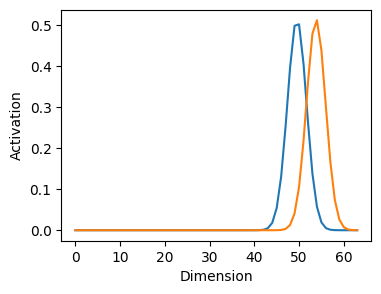

In [31]:
#Small figure
plt.figure(figsize=(4,3))
plt.plot(ground_truth[[0,1],:64].T)
plt.xlabel('Dimension')
plt.ylabel('Activation')
plt.show()

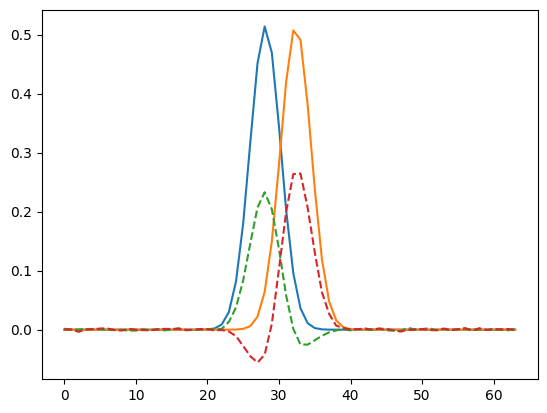

In [32]:
plt.plot(ground_truth[[2,3],64:128].T)
plt.plot(prediction[-1,[2,3],64:128].T, linestyle='--')

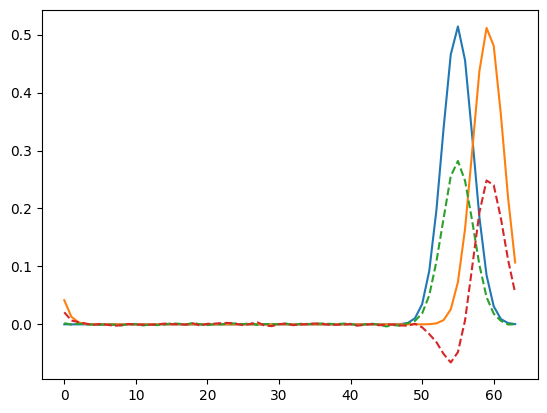

In [33]:
plt.plot(ground_truth[[4,5],128:192].T)
plt.plot(prediction[-1,[4,5],128:192].T, linestyle='--')

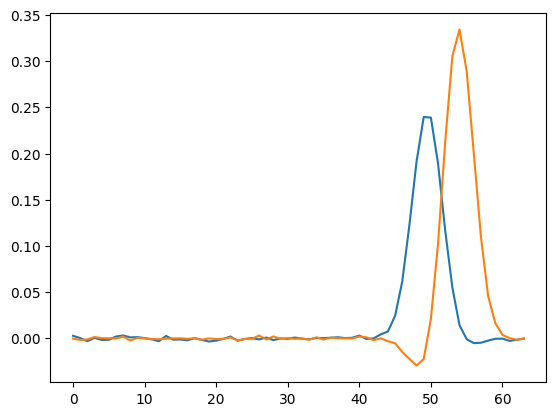

In [34]:
plt.plot(prediction[-1,[0,1],:64].T)

In [35]:
def plot_multirun_trajectories(
    multirun_folder,
    conditions,
    colors,
    ax=None,
    pred_name='prediction',
    pred_slot='color',
    shade='std',
    x_axis='steps',
    smooth=50,
    title=None,
    size=(6,4)
):
    """
    Plot average repulsion-metric trajectories across all seeds in a multirun folder,
    split by similarity condition (subgroup).

    Parameters
    ----------
    multirun_folder : str
        Path to the multirun folder whose immediate children are per-seed run dirs.
        E.g. 'multirun/2026-06-21/23-06-16'.
    conditions : dict or list
        If dict: {subgroup_name: display_label}.
        If list: subgroup names used as their own labels.
        Only the listed subgroups are plotted; order sets the legend order.
    colors : dict or list
        If dict: {subgroup_name: matplotlib_color}.
        If list: colors aligned with the order of `conditions`.
    ax : matplotlib.axes.Axes, optional
        Axes to draw on.  A new figure is created if None.
    pred_name : str
        Stem of the evaluation probe files (default 'prediction').
    pred_slot : str
        Output-slot label appended to file names (default 'color').
    shade : {'std', 'sem', None}
        How to shade around the mean: standard deviation across seeds ('std'),
        standard error ('sem'), or no shading (None).
    x_axis : {'steps', 'index'}
        X-axis unit: training steps or checkpoint index.
    smooth : int or None
        Width of the uniform moving-average window applied to each plotted curve.
        Set to None or 1 to disable smoothing.  Default is 50.
    title : str, optional
        Axes title.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    def _smooth(arr, w):
        """Apply a causal uniform moving average of width w (1-D array)."""
        if w is None or w <= 1:
            return arr
        kernel = np.ones(w) / w
        return np.convolve(arr, kernel, mode='full')[:len(arr)]

    # Normalise conditions / colors into dicts
    if isinstance(conditions, list):
        conditions = {sg: sg for sg in conditions}
    if isinstance(colors, list):
        colors = {sg: c for sg, c in zip(conditions.keys(), colors)}

    # Discover seed subfolders (any subdirectory whose name is an integer)
    seed_dirs = sorted(
        [
            os.path.join(multirun_folder, d)
            for d in os.listdir(multirun_folder)
            if os.path.isdir(os.path.join(multirun_folder, d))
        ],
        key=lambda p: int(os.path.basename(p)) if os.path.basename(p).isdigit() else float('inf'),
    )
    if not seed_dirs:
        raise ValueError(f"No seed subdirectories found in {multirun_folder!r}")

    # Per-condition accumulator: condition → list of (n_steps,) arrays, one per seed
    cond_trajectories = {sg: [] for sg in conditions}
    common_steps = None

    for seed_dir in seed_dirs:
        pred_file  = os.path.join(seed_dir, f'{pred_name}_combined_{pred_slot}.npy')
        gt_file    = os.path.join(seed_dir, f'{pred_name}_target_{pred_slot}.npy')
        rows_file  = os.path.join(seed_dir, f'{pred_name}_rows.json')
        steps_file = os.path.join(seed_dir, f'{pred_name}_steps.npy')

        if not all(os.path.exists(p) for p in (pred_file, gt_file, rows_file, steps_file)):
            continue  # skip incomplete runs

        prediction   = np.load(pred_file)    # (n_steps, n_samples, pred_dim)
        ground_truth = np.load(gt_file)      # (n_samples, pred_dim)
        steps_arr    = np.load(steps_file)   # (n_steps,)
        with open(rows_file) as f:
            row_info = json.load(f)

        if common_steps is None:
            common_steps = steps_arr

        n_samples = ground_truth.shape[0]
        n_groups  = n_samples // 2
        item_dim  = ground_truth.shape[1] // n_groups

        # Compute repulsion metric: (n_steps, n_samples)
        metric = np.empty((len(steps_arr), n_samples))
        for t in range(len(steps_arr)):
            vals = []
            for i in range(n_groups):
                gt1   = ground_truth[2*i,   (item_dim*i):(item_dim*(i+1))]
                gt2   = ground_truth[2*i+1, (item_dim*i):(item_dim*(i+1))]
                pred1 = prediction[t, 2*i,   (item_dim*i):(item_dim*(i+1))]
                pred2 = prediction[t, 2*i+1, (item_dim*i):(item_dim*(i+1))]
                vals.extend([signed_angle(gt1, gt2, pred1),
                              signed_angle(gt2, gt1, pred2)])
            metric[t] = vals

        # Average over samples within each condition → (n_steps,)
        for sg in conditions:
            mask = np.array([r['subgroup'] == sg for r in row_info])
            if mask.any():
                cond_trajectories[sg].append(metric[:, mask].mean(axis=1))

    if common_steps is None:
        raise RuntimeError("No complete seed runs found.")

    # Plot
    if ax is None:
        _, ax = plt.subplots(figsize=size)

    x = common_steps if x_axis == 'steps' else np.arange(len(common_steps))

    for sg, label in conditions.items():
        trajs = cond_trajectories[sg]
        if not trajs:
            continue
        arr   = np.stack(trajs)          # (n_seeds, n_steps)
        mean  = _smooth(arr.mean(axis=0), smooth)
        color = colors.get(sg)

        ax.plot(x, mean, label=label, color=color)

        if shade == 'std':
            err = _smooth(arr.std(axis=0), smooth)
        elif shade == 'sem':
            err = _smooth(arr.std(axis=0) / np.sqrt(len(trajs)), smooth)
        else:
            err = None

        if err is not None:
            ax.fill_between(x, mean - err, mean + err, alpha=0.2, color=color)

    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Trials' if x_axis == 'steps' else 'Checkpoint index')
    ax.set_ylabel('Repulsion metric (degrees)')
    ax.legend()
    if title:
        ax.set_title(title)

    return ax


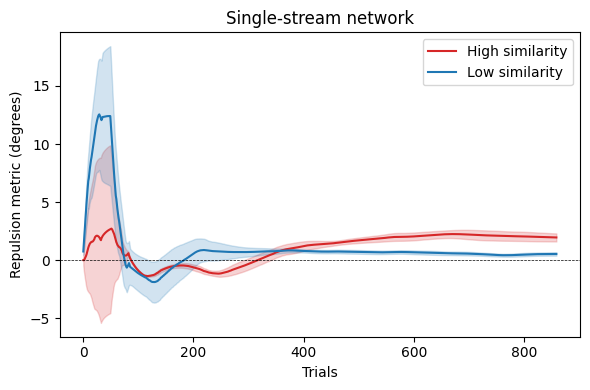

In [ ]:
ax = plot_multirun_trajectories(
    '../multirun/2026-06-23/11-26-19',
    conditions={'high_sim': 'High similarity', 'med_sim': 'Moderate similarity', 'low_sim': 'Low similarity'},
    colors={'high_sim': 'tab:red', 'med_sim': '#FFD700', 'low_sim': 'tab:blue'},
    shade='sem',
    title='Single-stream network',
    size=(6,4)
)
plt.tight_layout()
plt.show()


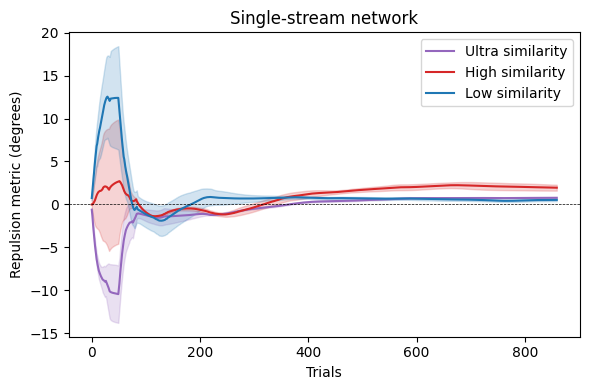

In [47]:
ax = plot_multirun_trajectories(
    '../multirun/2026-06-23/11-27-46',
    conditions={'ultra_sim': 'Ultra similarity', 'high_sim': 'High similarity', 'low_sim': 'Low similarity'},
    colors={'ultra_sim': 'tab:purple', 'high_sim': 'tab:red', 'low_sim': 'tab:blue'},
    shade='sem',
    title='Single-stream network',
    size=(6,4)
)
plt.tight_layout()
plt.show()


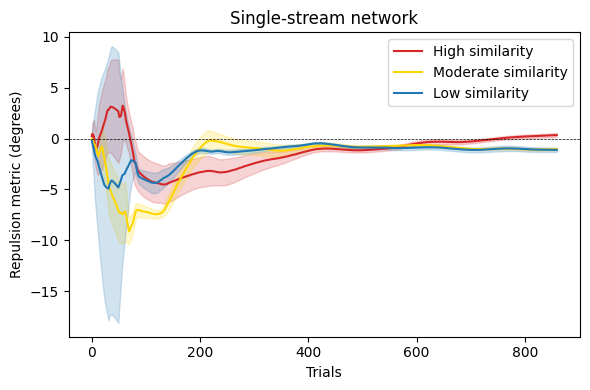

In [49]:
ax = plot_multirun_trajectories(
    '../multirun/2026-06-23/11-31-43',
    conditions={'high_sim': 'High similarity', 'med_sim': 'Moderate similarity', 'low_sim': 'Low similarity'},
    colors={'high_sim': 'tab:red', 'med_sim': '#FFD700', 'low_sim': 'tab:blue'},
    shade='sem',
    title='Single-stream network',
    size=(6,4)
)
plt.tight_layout()
plt.show()


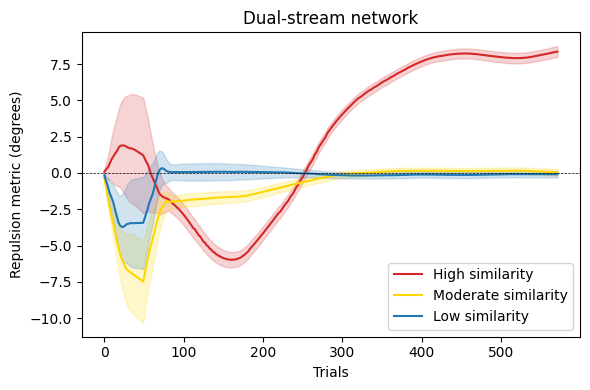

In [169]:
ax = plot_multirun_trajectories(
    '../multirun/2026-06-21/23-21-43',
    conditions={'high_sim': 'High similarity', 'med_sim': 'Moderate similarity', 'low_sim': 'Low similarity'},
    colors={'high_sim': 'tab:red', 'med_sim': '#FFD700', 'low_sim': 'tab:blue'},
    shade='sem',
    title='Dual-stream network',
)
plt.tight_layout()
plt.show()


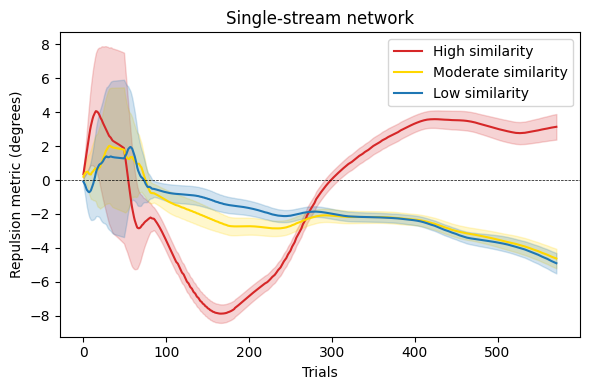

In [172]:
ax = plot_multirun_trajectories(
    '../multirun/2026-06-22/01-50-06',
    conditions={'high_sim': 'High similarity', 'med_sim': 'Moderate similarity', 'low_sim': 'Low similarity'},
    colors={'high_sim': 'tab:red', 'med_sim': '#FFD700', 'low_sim': 'tab:blue'},
    shade='sem',
    title='Single-stream network',
    size=(6,4)
)
plt.tight_layout()
plt.show()


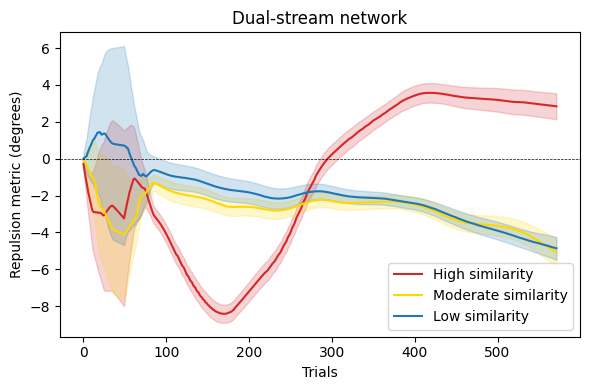

In [173]:
ax = plot_multirun_trajectories(
    '../multirun/2026-06-22/02-10-11',
    conditions={'high_sim': 'High similarity', 'med_sim': 'Moderate similarity', 'low_sim': 'Low similarity'},
    colors={'high_sim': 'tab:red', 'med_sim': '#FFD700', 'low_sim': 'tab:blue'},
    shade='sem',
    title='Dual-stream network',
)
plt.tight_layout()
plt.show()
